# Task 1: Build & Evaluate a Linear Regression Model (House Price Predictor)

### 1. Importing Necessary Libraries 

In [17]:
import pandas as pd              # For data manipulation and analysis
import numpy as np               # For numerical operations
import matplotlib.pyplot as plt  # For data visualization
import seaborn as sns            # For statistical data visualization
import pickle                    # For saving and loading Python objects
import math                      # For mathematical operations

from sklearn.datasets import fetch_california_housing                           # For loading the California housing dataset
from sklearn.model_selection import train_test_split                            # For splitting the dataset into training and testing sets
from sklearn.preprocessing import StandardScaler                                # For feature scaling
from sklearn.linear_model import LinearRegression                               # For linear regression modeling
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score   # For model evaluation metrics 

### 2. Loading Dataset 

In [18]:
data = fetch_california_housing(as_frame=True)                          # Load the California housing dataset as a DataFrame
df = pd.concat([data.data, data.target.rename("MedHouseVal")], axis=1)  # Combine features and target into a single DataFrame
display(df.head())                                                      # Display the first few rows of the DataFrame

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### 3. Exploratory Data Analysis

In [19]:
# Display the shape of the dataset
print("Dataset shape:", df.shape)  # Print the shape of the dataset

Dataset shape: (20640, 9)


In [20]:
# Display information about the dataset
print("Dataset information:")
df.info()                          # Display information about the dataset, including data types and non-null counts

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [21]:
# Display summary statistics of the dataset
print("Summary statistics of the dataset:") 
display(df.describe())             # Display summary statistics of the dataset

Summary statistics of the dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [22]:
# Check for missing values in the dataset
print("Missing values in the dataset:")
display(df.isnull().sum())           # Display the count of missing values in each column

Missing values in the dataset:


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

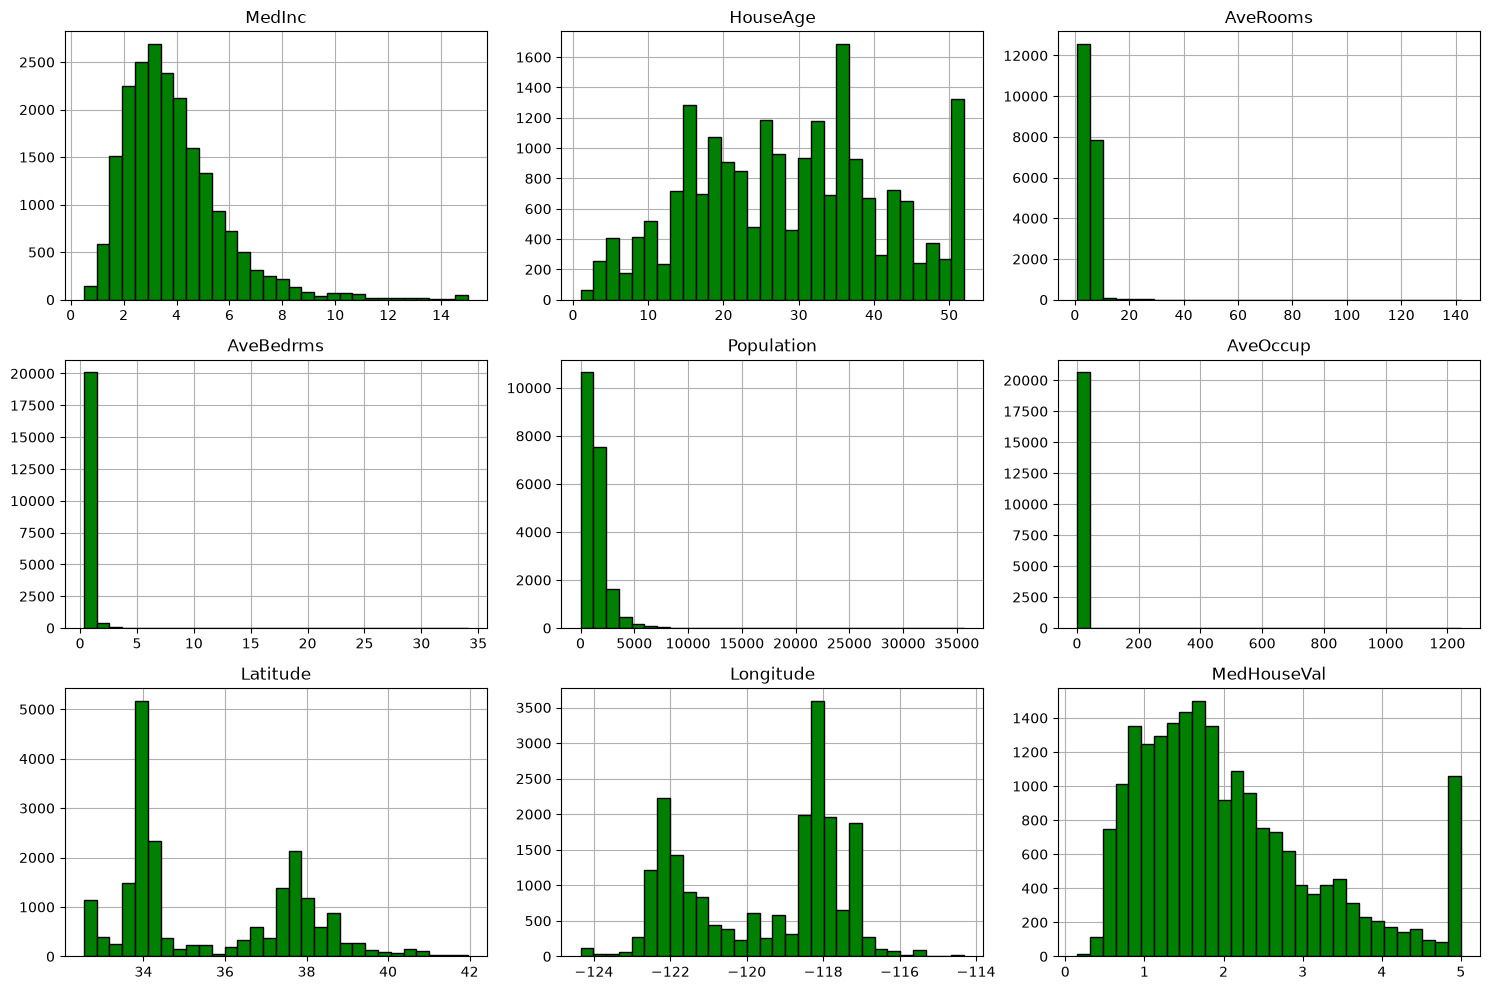

In [32]:
# Visualize the distribution of each feature in the dataset using histograms
axes = df.hist(
    bins=30,              # Number of bins for the histogram
    figsize=(15, 10),     # Size of the figure
    edgecolor='black',    # Color of the edges of the bars
    zorder=2,             # Z-order for layering the histogram bars
    color='green'         # Color of the bars
)

for ax in axes.flatten():
    ax.grid(True, zorder=0)      # Grid behind bars

plt.tight_layout()
plt.show()                        

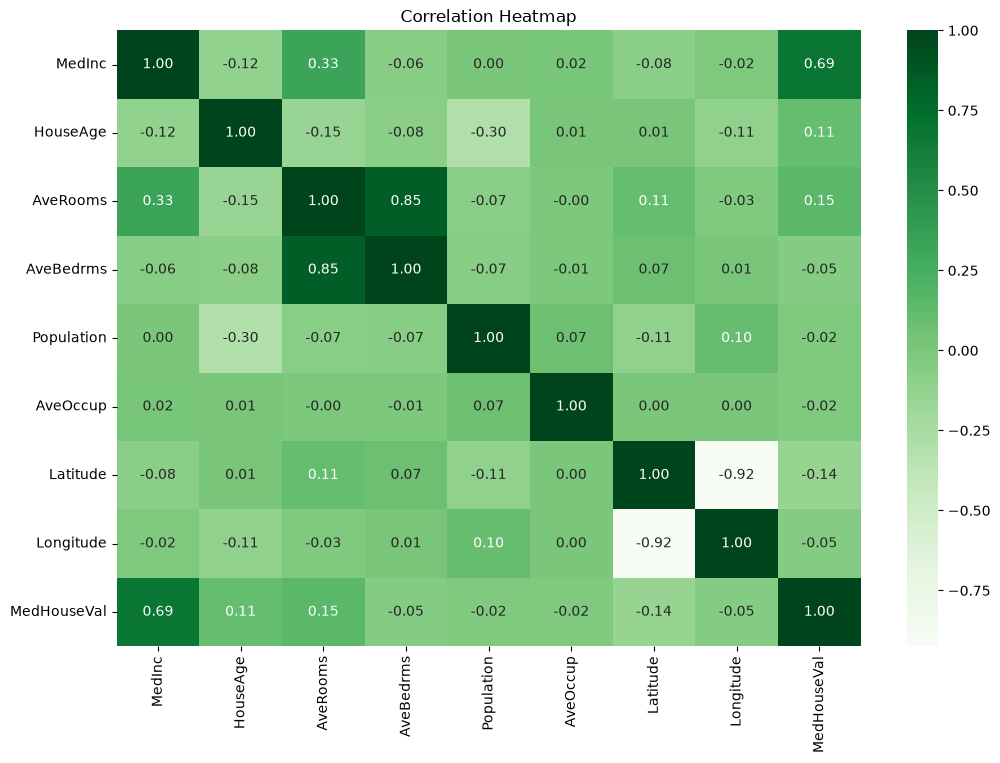

In [24]:
# Visualize the correlation matrix of the dataset using a heatmap
plt.figure(figsize=(12, 8))                              # Set the figure size for the heatmap
corr = df.corr()                                         # Calculate the correlation matrix of the dataset
sns.heatmap(corr, annot=True, cmap='Greens', fmt=".2f")  # Create a heatmap of the correlation matrix
plt.title("Correlation Heatmap")
plt.show()

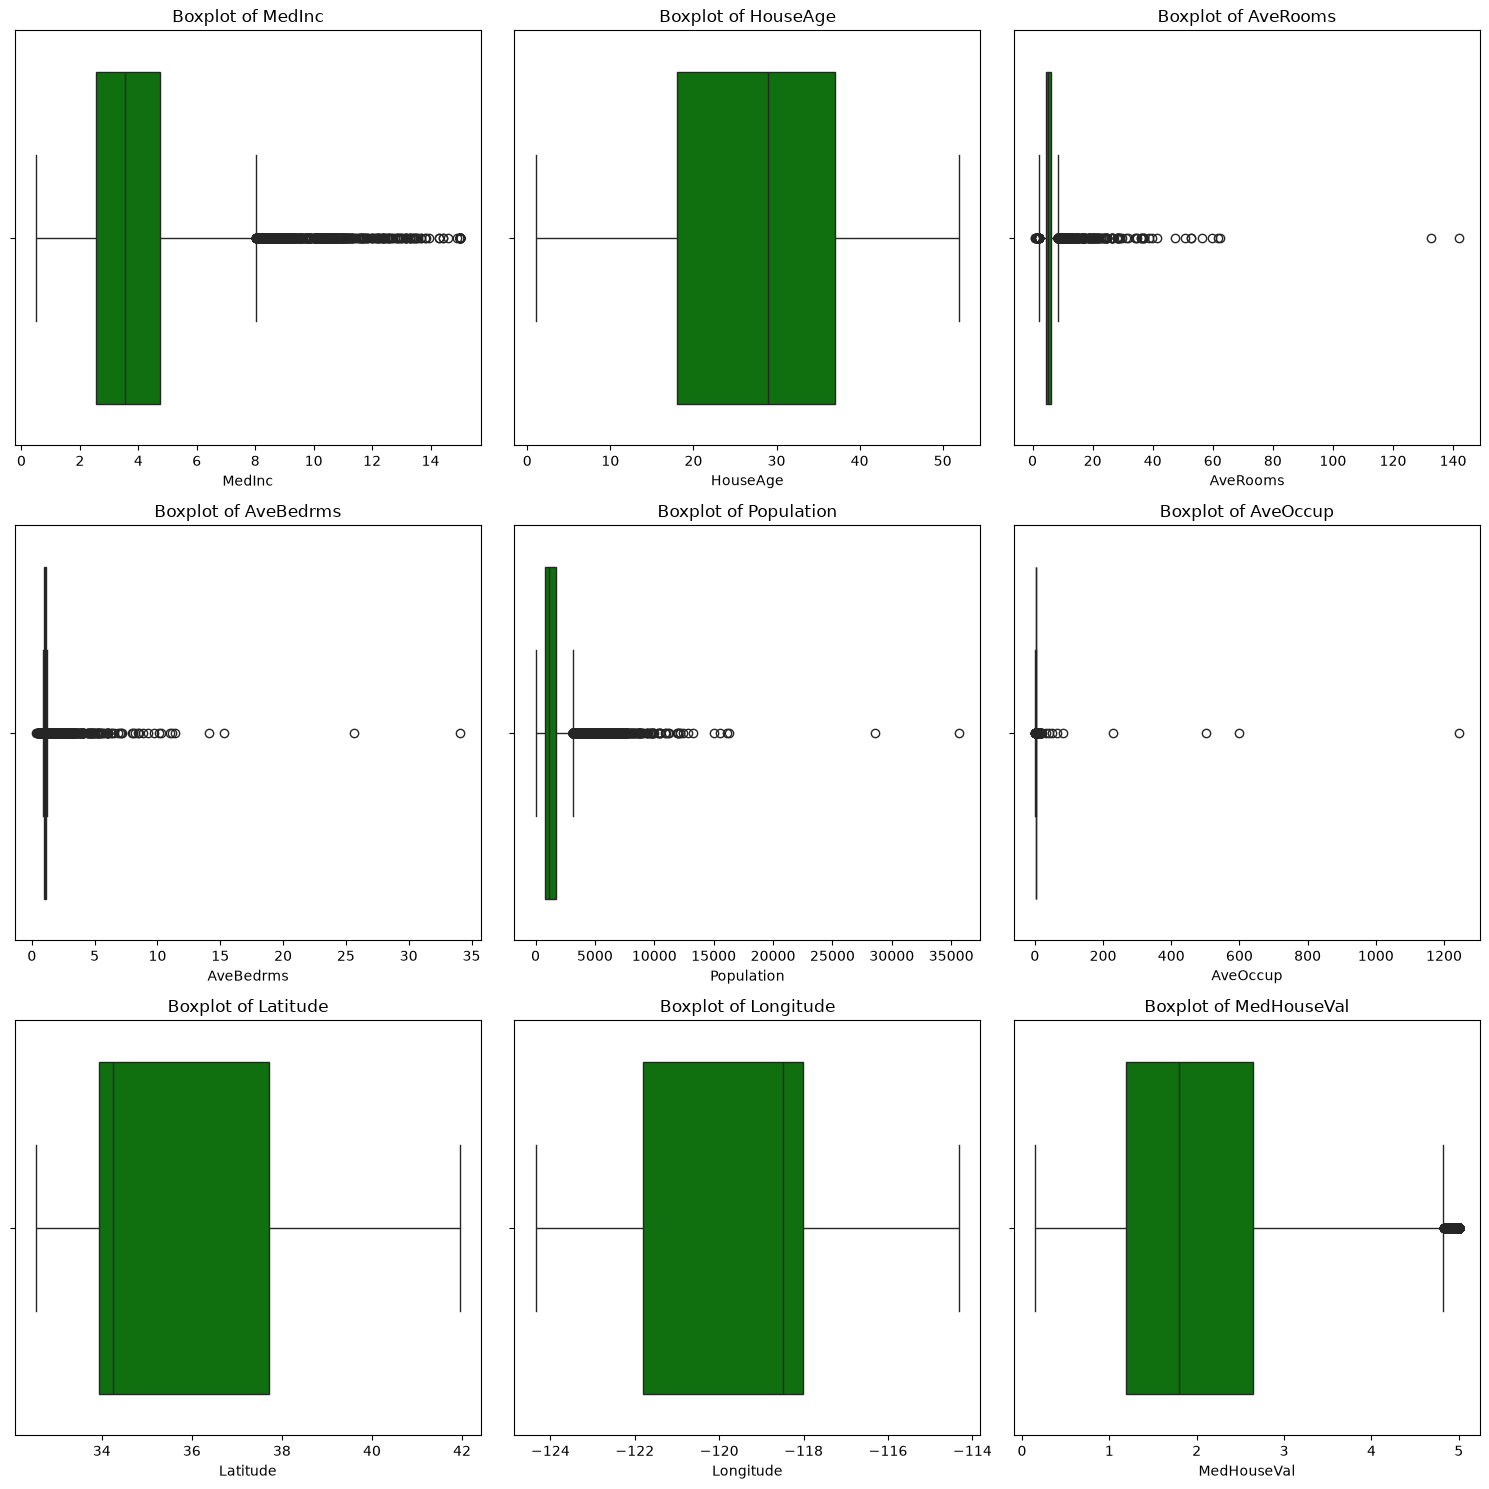

In [25]:
# Detect the outliers in the dataset using boxplots for each feature
n_cols = len(df.columns)
cols = 3
rows = math.ceil(n_cols / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.boxplot(x=df[col], color='green', ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel(col)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

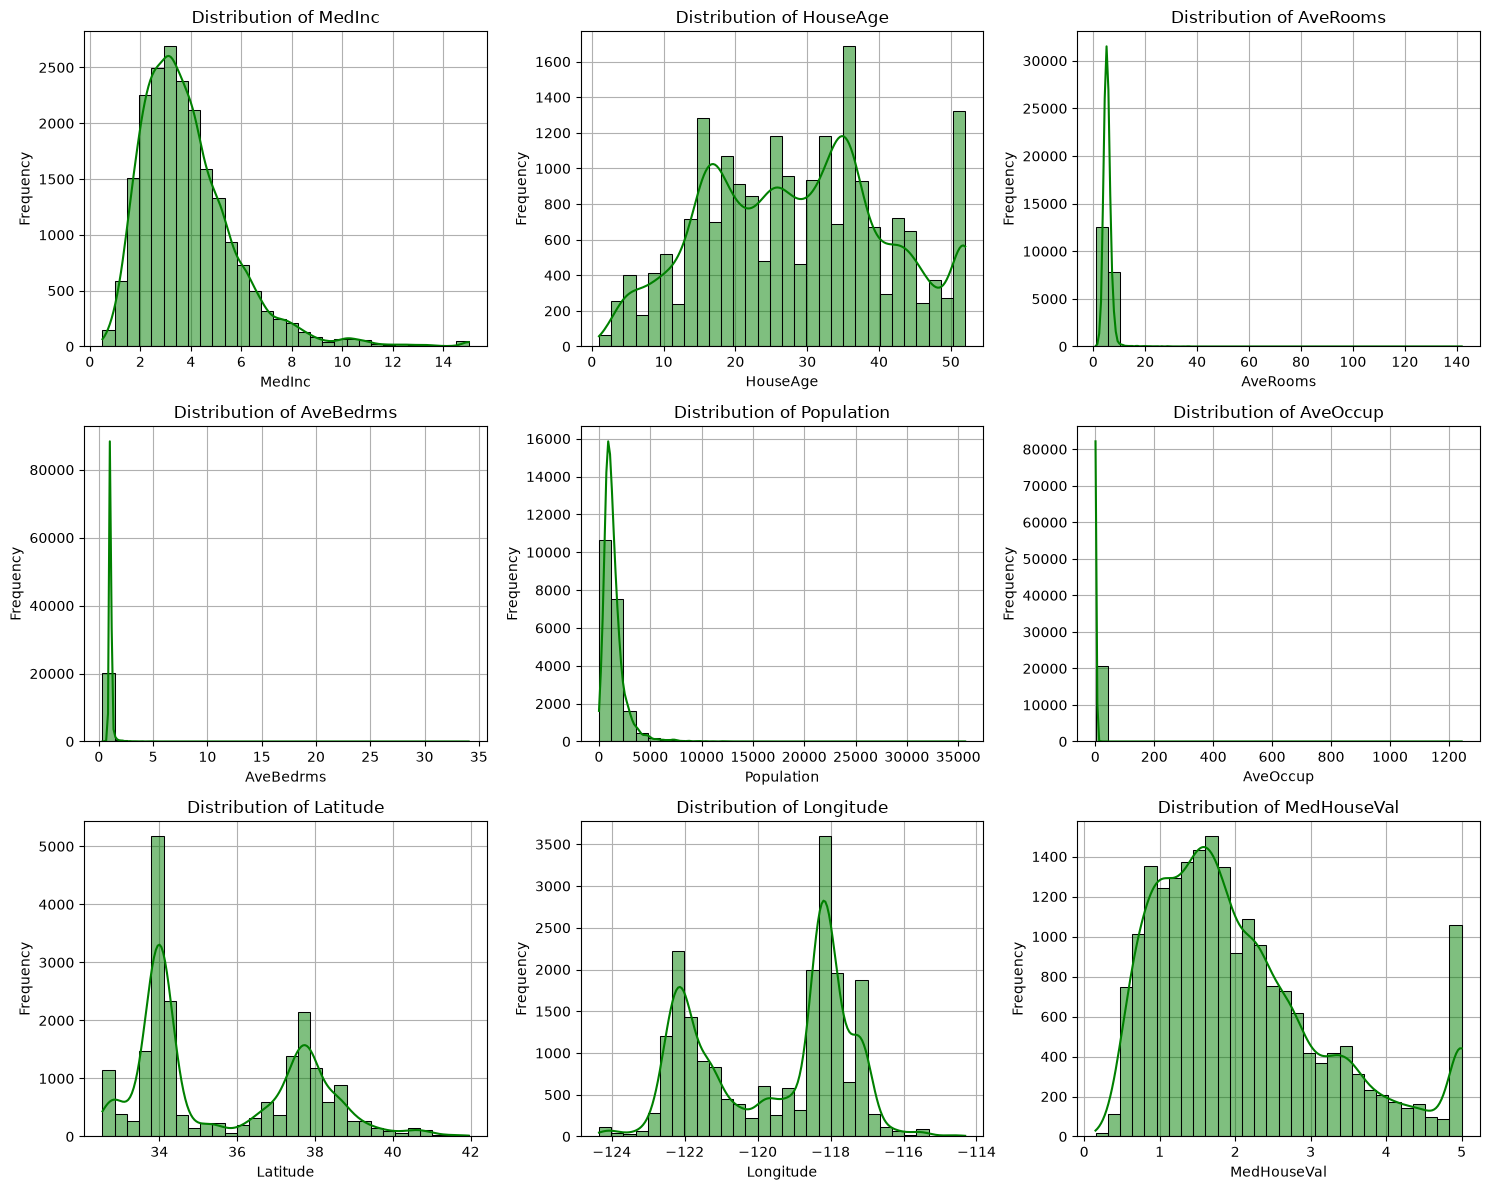

In [26]:
# Visualize the distribution of each feature in the dataset using histograms with KDE overlay
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for ax, column in zip(axes, df.columns):
    sns.histplot(
        df[column],                     # data for this feature
        bins=30,                        # number of histogram bins
        kde=True,                       # overlay a KDE for smoother distribution view
        color='green',
        ax=ax                           # plot into the current subplot axis
    )
    ax.set_title(f'Distribution of {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequency')
    ax.grid(True)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### 4. Pre-Processing

In [27]:
# Train/Test split of the dataset
X = df.drop("MedHouseVal", axis=1)  # Features (all columns except the target)
y = df["MedHouseVal"]               # Target variable (Median House Value)

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
    )  # Split the dataset into training and testing sets

In [28]:
# Feature scaling using StandardScaler
scaler = StandardScaler()                      # Create an instance of StandardScaler for feature scaling
scaler.fit(X_train)                            # Fit the scaler on the training data  
X_train_scaled = scaler.transform(X_train)     # Transform the training data
X_test_scaled = scaler.transform(X_test)       # Transform the testing data

### 5. Model Training

In [29]:
model = LinearRegression()                    # Create an instance of LinearRegression
model.fit(X_train_scaled, y_train)            # Fit the model on the scaled training data
print("Model trained successfully.")

Model trained successfully.


### 6. Evaluation

In [30]:
y_pred = model.predict(X_test_scaled)          # Predict the target variable for the test set

# Evaluate the model using various metrics
mae = mean_absolute_error(y_test, y_pred)      # Calculate Mean Absolute Error
mse = mean_squared_error(y_test, y_pred)       # Calculate Mean Squared Error
rmse = np.sqrt(mse)                            # Calculate Root Mean Squared Error
r2 = r2_score(y_test, y_pred)                  # Calculate R-squared score

# Print the evaluation metrics
print(f"Mean Absolute Error (MAE):      {mae:.4f}")
print(f"Mean Squared Error (MSE):       {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2):                 {r2:.4f}")

Mean Absolute Error (MAE):      0.5332
Mean Squared Error (MSE):       0.5559
Root Mean Squared Error (RMSE): 0.7456
R-squared (R2):                 0.5758


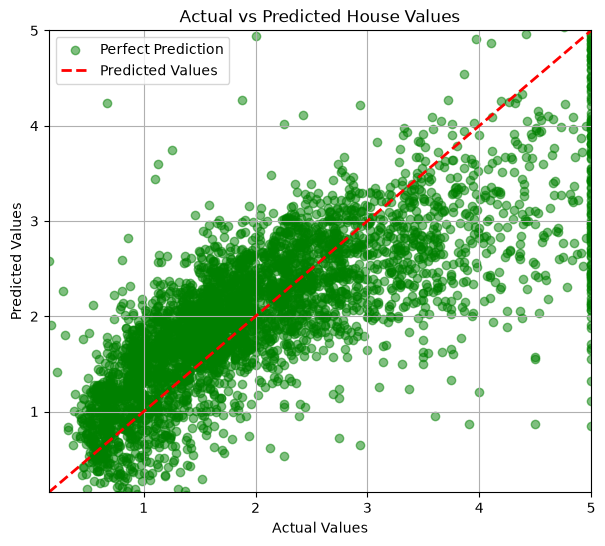

In [31]:
# Visualize the actual vs predicted values using a scatter plot
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted House Values")
plt.xlim([y_test.min(), y_test.max()])
plt.ylim([y_test.min(), y_test.max()])
plt.legend(["Perfect Prediction", "Predicted Values"], loc="upper left")
plt.grid(True)
plt.show()

## Conclusion 
The Linear Regression model achieved a Mean Absolute Error (MAE) of 0.5332. This value suggests that the average deviation of predicted values of median house value from their actual value is 0.53 approximately. The Mean Squared Error (MSE) is 0.5559, while the Root Mean Squared Error (RMSE) is 0.7456. Both the MSE and RMSE show that the model has a moderate prediction error. 
The RMSE specifically points to the existence of some large prediction errors in the model. The model produced an R-squared (R) score of 0.5758. This shows that the model can explain approximately 57.58% of the variation in house prices based on the features. The remaining approximately 42.42% variation remains unexplained by the model. 
This fact implies that a Linear Regression model alone cannot perfectly explain the relationships in the California Housing dataset. 

From the Actual vs Predicted scatter plot, most of the predictions align along the diagonal line which represents a perfect prediction. It confirms that the model has learned the trend. However, beyond the average house values, the predictions start diverging from the line.

This means that the model has difficulty in accurately estimating the prices for high-value homes. This result is anticipated as California Housing dataset is a complex non-linear dataset, and the values for the target variable are capped at 5.0, so there are a lot of predictions on the max value of the target. In conclusion, Linear Regression gave reasonable baseline predictions for this dataset, but this model is not highly accurate. 

More advanced models like Random Forest Regressor, Gradient Boosting, and XGBoost can give better predictions for this dataset by modelling non-linearities.